In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
OBS_PATH = "/scratch/dlhogan/ess-project-data/meteorological-data/SNOTEL"
OBS_OPTIONS = ['380_Butte_sntl_obs.csv', 
               'SLI_SLIDE_CANYON_cdec_obs.csv', 
               'DAN_DANA_MEADOWS_cdec_obs.csv', 
               'TGC_TUOLUMNE_R_AT_THE_GRAND_CYN_OF_TUOLUMNE_cdec_obs.csv', 
               'GYP_GAYLOR_PIT_cdec_obs.csv', 
               'TUM_TUOLUMNE_MEADOWS_cdec_obs.csv']
BILLY_PATH = "/storage/dlhogan/precipitation-rodeo/data/processed/billy_barr/billy_barr_20011001-20251025_30min.nc"

ppt_dfs = []
elevations = {}
for obs in OBS_OPTIONS:
    obs_path = f"{OBS_PATH}/{obs}"
    obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
    elevation = int(obs_df['geometry'][0].split(' ')[-1].replace(')', '')) / 3.28084  # convert feet to meters
    obs_df.set_index('datetime', inplace=True)
    if 'PRECIPITATION' not in obs_df.columns:
        print (f"PRECIPITATION column not found in {obs}. Skipping this file.")
        continue
    obs_df = obs_df.resample('D').sum()[['PRECIPITATION']]
    # convert to mm from inches
    obs_df['PRECIPITATION'] = obs_df['PRECIPITATION'] * 25.4
    obs_df.index = pd.to_datetime(obs_df.index.date)
    # rename column
    obs_df.rename(columns={'PRECIPITATION': obs.split('.csv')[0].replace('_cdec_obs', '').replace('_sntl_obs', '')}, inplace=True)
    elevations[obs.split('.csv')[0].replace('_cdec_obs', '').replace('_sntl_obs', '')] = elevation
    ppt_dfs.append(obs_df)

PRECIPITATION column not found in SLI_SLIDE_CANYON_cdec_obs.csv. Skipping this file.
PRECIPITATION column not found in TGC_TUOLUMNE_R_AT_THE_GRAND_CYN_OF_TUOLUMNE_cdec_obs.csv. Skipping this file.


In [3]:
bb_ds = xr.open_dataset(BILLY_PATH)
# filter bad data
bb_ds = bb_ds.where((bb_ds['precip_bad_flag'] == 0) & (bb_ds['precip'] >= 0))
bb_df = bb_ds['precip'].to_dataframe().resample('D').sum()
bb_df.rename(columns={'precip': 'Billy_Barr'}, inplace=True)
elevations["Billy_Barr"] = 2917  # meters
ppt_dfs.append(bb_df)

<Axes: >

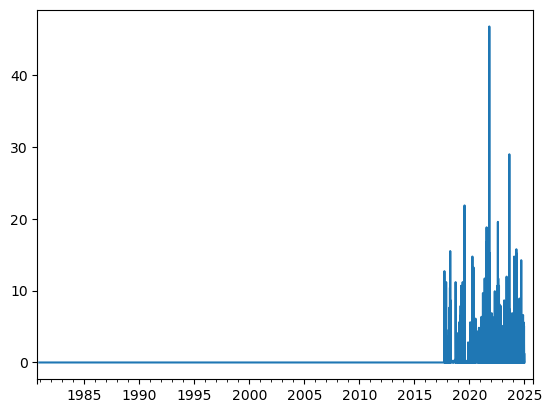

In [4]:
# merge the ppt_dfs on the index (datetime) using outer join to keep all dates
merged_df = pd.concat(ppt_dfs, axis=1, join='outer')
merged_df = merged_df[(merged_df>=0) & (merged_df<=250)]  # filter out unrealistic values
merged_df['DAN_DANA_MEADOWS'].plot()

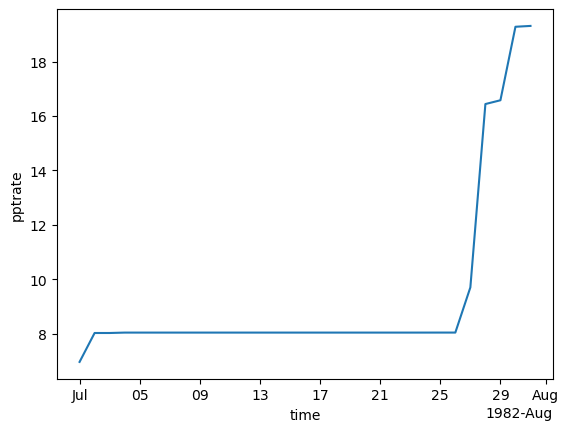

In [5]:
# pull in forcing data for one location
from glob import glob
FORCING_PATH = "/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/forcing/basin_averaged_data"
FORCING_FILES = glob(f"{FORCING_PATH}/*.nc")
(xr.open_dataset(FORCING_FILES[0])['pptrate'] * 3600).resample(time='D').sum().mean(dim='hru').cumsum().plot(label='Forcing')

/tmp/ipykernel_273797/1740029665.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', 256)


278.2684904761905
757.956976898398
173.37616666666665


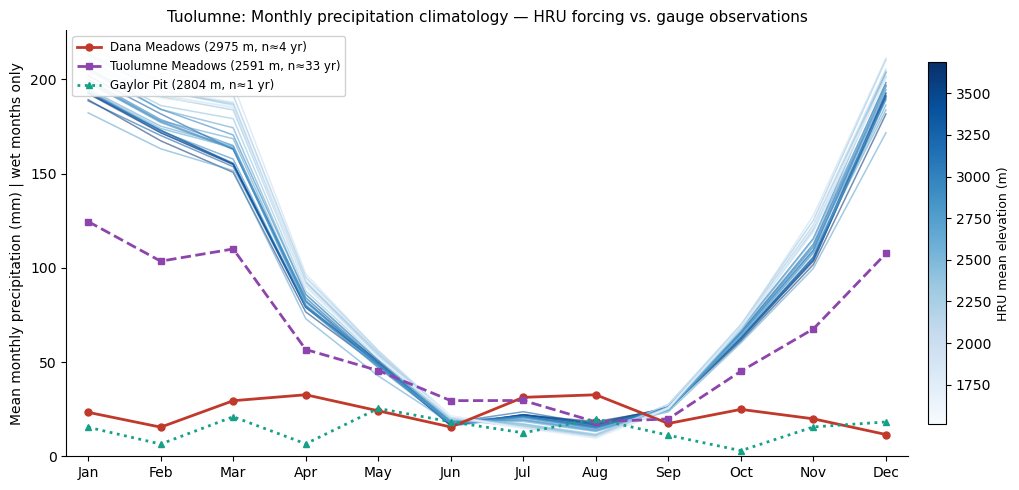

In [6]:

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import geopandas as gpd
from glob import glob

# ── HRU metadata ─────────────────────────────────────────────────────────────
shp = gpd.read_file(
    '/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect'
    '/shapefiles/catchment/Tuolumne_River_distributed_elevAspect_HRUs_elevation_aspect.shp'
)
ac_col = 'aspectClass' if 'aspectClass' in shp.columns else 'aspectClas'
hru_meta = shp[['HRU_ID', 'elevClass', ac_col, 'elev_mean']].sort_values('HRU_ID').set_index('HRU_ID')

# ── HRU forcing: monthly precip climatology ───────────────────────────────────
FORCING_PATH = (
    '/scratch/dlhogan/ess-project-data'
    '/domain_Tuolumne_River_distributed_elevAspect/forcing/basin_averaged_data'
)
files = sorted(glob(f'{FORCING_PATH}/*.nc'))

records = []
for f in files:
    ym = f.split('metsim_')[-1].replace('.nc', '')
    year, month = int(ym[:4]), int(ym[4:6])
    with xr.open_dataset(f) as ds:
        # pptrate [mm/s] * 3600 s/hr * n_hours = mm/month per HRU
        ppt = (ds['pptrate'] * 3600).sum(dim='time').values   # shape (n_hru,)
    records.append({'year': year, 'month': month, 'ppt': ppt})

# Build DataFrame: rows = year-months, cols = HRU_IDs (1-based)
n_hru = len(hru_meta)
hru_ids = np.arange(1, n_hru + 1)
forcing_df = pd.DataFrame(
    [r['ppt'] for r in records],
    index=pd.MultiIndex.from_tuples([(r['year'], r['month']) for r in records], names=['year', 'month']),
    columns=hru_ids,
)

# Climatological monthly mean — exclude months with <= 1 mm (treat as dry/missing)
forcing_df_wet = forcing_df.where(forcing_df > 1.0)
hru_clim = forcing_df_wet.groupby(level='month').mean()   # shape (12, n_hru)

# ── Observations ─────────────────────────────────────────────────────────────
OBS_PATH = '/scratch/dlhogan/ess-project-data/meteorological-data/SNOTEL'
STATIONS = {
    'Dana Meadows':     ('DAN_DANA_MEADOWS_cdec_obs.csv',     2975),
    'Tuolumne Meadows': ('TUM_TUOLUMNE_MEADOWS_cdec_obs.csv', 2591),
    'Gaylor Pit':       ('GYP_GAYLOR_PIT_cdec_obs.csv',       2804),
}
STATION_COLORS = {
    'Dana Meadows':     '#c0392b',
    'Tuolumne Meadows': '#8e44ad',
    'Gaylor Pit':       '#16a085',
}

obs_clim = {}
obs_nyears = {}
for name, (fname, elev) in STATIONS.items():
    df = pd.read_csv(f'{OBS_PATH}/{fname}', parse_dates=['datetime'])
    df = df.set_index('datetime').sort_index()
    if 'PRECIPITATION' not in df.columns:
        continue
    daily = df['PRECIPITATION'].resample('D').sum() * 25.4   # inches → mm
    daily = daily[(daily >= 0) & (daily <= 250)]
    monthly = daily.resample('ME').sum()
    # exclude months with <= 1 mm
    monthly_wet = monthly.where(monthly > 1.0)
    clim = monthly_wet.groupby(monthly_wet.index.month).mean()
    obs_clim[name] = clim
    obs_nyears[name] = monthly_wet.groupby(monthly_wet.index.month).count().min()

# ── Colormap: elevation → colour ─────────────────────────────────────────────
elev_vals = hru_meta['elev_mean'].values
norm = mcolors.Normalize(vmin=elev_vals.min(), vmax=elev_vals.max())
cmap = cm.get_cmap('Blues', 256)

# ── Plot ─────────────────────────────────────────────────────────────────────
months = np.arange(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 5))

# HRU lines — skip months where ALL HRUs are NaN (truly dry months)
for hru_id in hru_ids:
    elev = hru_meta.loc[hru_id, 'elev_mean']
    color = cmap(norm(elev))
    y = hru_clim[hru_id].values   # NaN where month was always dry
    ax.plot(months, y, color=color, alpha=0.55, linewidth=1.1, zorder=2)

# Station lines
STATION_STYLES = {
    'Dana Meadows':     dict(ls='-',  marker='o', ms=5),
    'Tuolumne Meadows': dict(ls='--', marker='s', ms=5),
    'Gaylor Pit':       dict(ls=':',  marker='^', ms=5),
}
for name, clim in obs_clim.items():
    ny = obs_nyears[name]
    label = f'{name} ({STATIONS[name][1]} m, n≈{ny} yr)'
    print(np.sum(clim.reindex(months).values))
    ax.plot(months, clim.reindex(months).values,
            color=STATION_COLORS[name], linewidth=2.0, zorder=5,
            label=label, **STATION_STYLES[name])

# Colorbar for HRU elevations
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.85)
cb.set_label('HRU mean elevation (m)', fontsize=9)

ax.set_xticks(months)
ax.set_xticklabels(month_labels)
ax.set_ylabel('Mean monthly precipitation (mm) | wet months only', fontsize=10)
ax.set_title('Tuolumne: Monthly precipitation climatology — HRU forcing vs. gauge observations', fontsize=11)
ax.legend(fontsize=8.5, framealpha=0.9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0.7, 12.3)
ax.set_ylim(bottom=0)

fig.tight_layout()
plt.show()


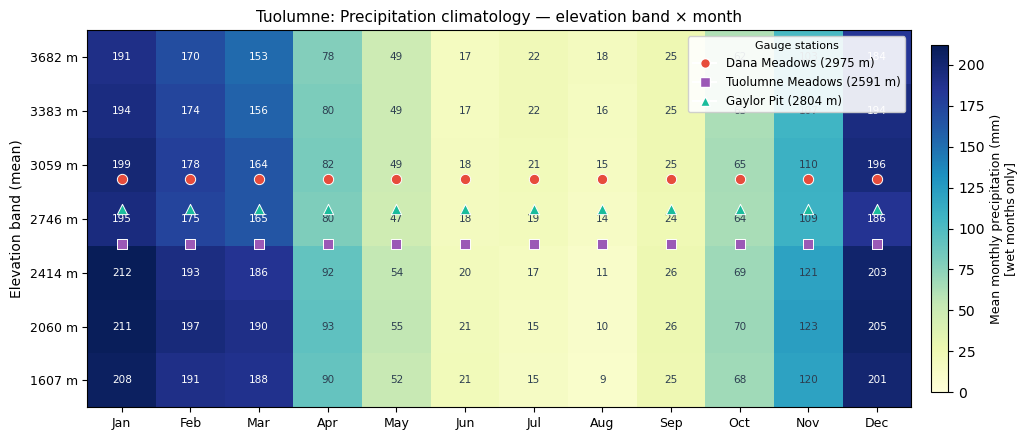

In [7]:

# ── Elevation-band × month heatmap ───────────────────────────────────────────
# Collapses all aspect HRUs within each elevation band into a single mean,
# then shows climatological monthly precipitation as a heatmap.
# Observation stations are overlaid as scatter points at their actual elevation.

from matplotlib.lines import Line2D

# Band mean elevation and member HRU IDs
band_info = (
    hru_meta.reset_index()
    .groupby('elevClass')
    .agg(hru_ids=('HRU_ID', list), elev_mean=('elev_mean', 'mean'))
    .sort_index(ascending=True)   # low elevation first → high elevation last
)

# Mean ppt across all aspect HRUs per elevation band, for every year-month
band_df = pd.DataFrame(index=forcing_df.index)
for ec, row in band_info.iterrows():
    cols = [h for h in row['hru_ids'] if h in forcing_df.columns]
    band_df[ec] = forcing_df[cols].mean(axis=1)

# Wet-months-only climatological mean per band
band_clim = band_df.where(band_df > 1.0).groupby(level='month').mean()  # (12, n_bands)

# ── Heatmap arrays ────────────────────────────────────────────────────────────
elev_bands  = band_clim.columns.tolist()          # ascending band IDs
band_elevs  = np.array([band_info.loc[ec, 'elev_mean'] for ec in elev_bands])
heatmap     = band_clim[elev_bands].T.values      # (n_bands, 12) — low→high on y

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
months = np.arange(1, 13)
n_bands = len(elev_bands)

fig, ax = plt.subplots(figsize=(11, 4.5))

vmax = np.nanmax(heatmap)
im = ax.pcolormesh(
    np.arange(0.5, 13.5),
    np.arange(n_bands + 1),
    heatmap,
    cmap='YlGnBu',
    vmin=0,
    vmax=vmax,
    shading='flat',
)
cb = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.92)
cb.set_label('Mean monthly precipitation (mm)\n[wet months only]', fontsize=9)

# Cell value annotations
for i in range(n_bands):
    for j, m in enumerate(months):
        val = heatmap[i, j]
        if not np.isnan(val):
            txt_color = 'white' if val > vmax * 0.65 else '#2c3e50'
            ax.text(m, i + 0.5, f'{val:.0f}', ha='center', va='center',
                    fontsize=7.5, color=txt_color, fontweight='500')

# Y-axis: one tick per band, labelled with mean elevation
ax.set_yticks(np.arange(n_bands) + 0.5)
ax.set_yticklabels([f'{e:.0f} m' for e in band_elevs], fontsize=9)
ax.set_ylabel('Elevation band (mean)', fontsize=10)
ax.set_xticks(months)
ax.set_xticklabels(month_labels, fontsize=9)
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0, n_bands)

# Overlay observation stations as scatter at interpolated y-position
STATION_COLORS_HM = {'Dana Meadows': '#e74c3c', 'Tuolumne Meadows': '#9b59b6', 'Gaylor Pit': '#1abc9c'}
STATION_MARKERS_HM = {'Dana Meadows': 'o', 'Tuolumne Meadows': 's', 'Gaylor Pit': '^'}
for name, clim in obs_clim.items():
    stn_elev = STATIONS[name][1]
    y_pos = np.interp(stn_elev, band_elevs, np.arange(n_bands) + 0.5,
                      left=0.3, right=n_bands - 0.3)
    xs = [m for m in months if not np.isnan(clim.get(m, np.nan))]
    ys = [y_pos] * len(xs)
    ax.scatter(xs, ys, s=55, color=STATION_COLORS_HM[name], zorder=6,
               marker=STATION_MARKERS_HM[name], edgecolors='white', linewidths=0.7)

legend_handles = [
    Line2D([0], [0], marker=STATION_MARKERS_HM[n], color='w',
           markerfacecolor=STATION_COLORS_HM[n], markersize=7,
           markeredgecolor='white',
           label=f'{n} ({STATIONS[n][1]} m)')
    for n in obs_clim
]
ax.legend(handles=legend_handles, fontsize=8.5, loc='upper right',
          framealpha=0.9, title='Gauge stations', title_fontsize=8)

ax.set_title('Tuolumne: Precipitation climatology — elevation band × month', fontsize=11)
fig.tight_layout()
plt.show()


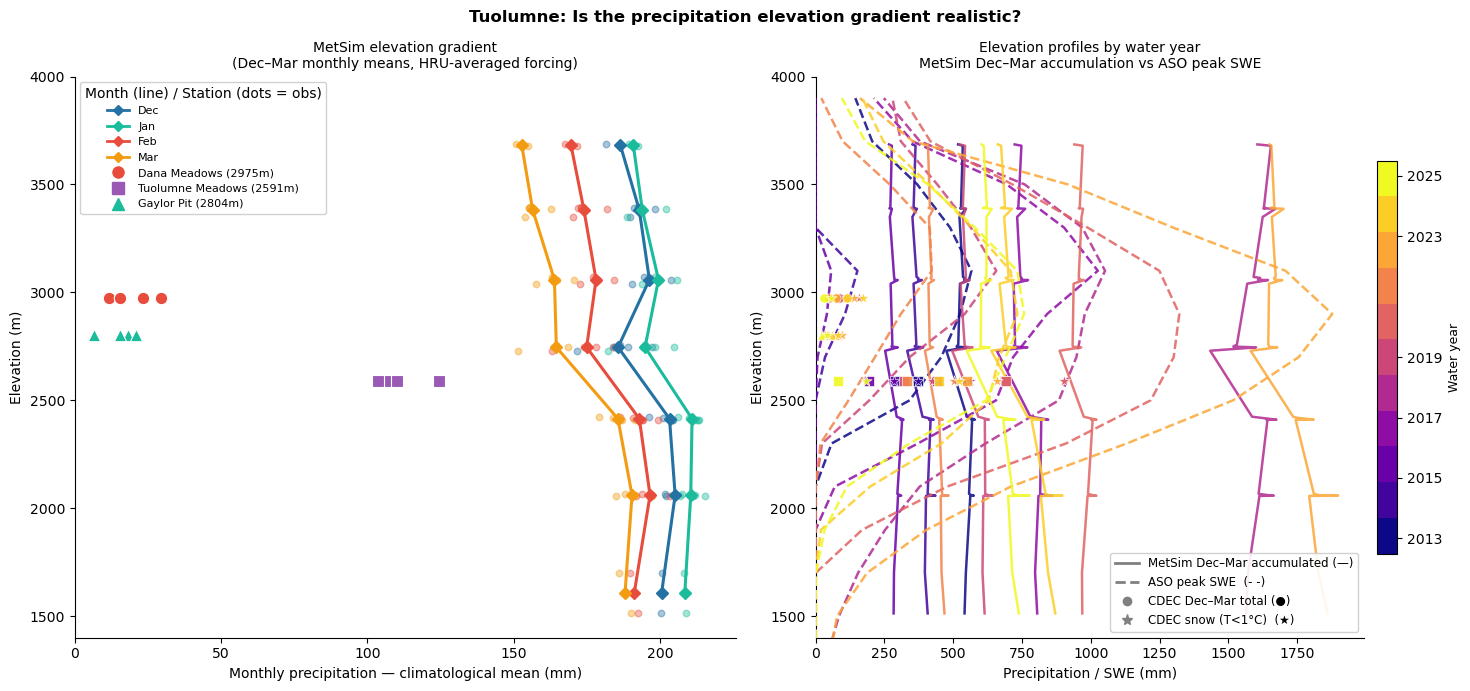

In [8]:

# ── MetSim elevation gradient + ASO SWE comparison ───────────────────────────
#
# Replaces PRISM with MetSim HRU-averaged forcing from basin_averaged_data.
# Elevation comes directly from shapefile — no grid interpolation artifacts.
#
# Panel 1: Dec–Mar monthly precip by HRU elevation (climatological mean)
#   Dots = individual HRUs (aspect spread within bands), diamonds = band mean
# Panel 2: Per-year Dec–Mar MetSim accumulation vs ASO peak SWE by elevation

from pathlib import Path
import re
import rioxarray as rxr
from matplotlib.lines import Line2D

ASO_DIR   = Path('/scratch/dlhogan/ess-project-data/geospatial-data/ASO/Tuolumne')
DEM_PATH  = ('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect'
             '/attributes/elevation/dem/domain_Tuolumne_River_lumped_elv.tif')
OBS_PATH_ = '/scratch/dlhogan/ess-project-data/meteorological-data/SNOTEL'

STATIONS_ = {
    'Dana Meadows':     ('DAN_DANA_MEADOWS_cdec_obs.csv',     2975),
    'Tuolumne Meadows': ('TUM_TUOLUMNE_MEADOWS_cdec_obs.csv', 2591),
    'Gaylor Pit':       ('GYP_GAYLOR_PIT_cdec_obs.csv',       2804),
}
STN_COLORS = {'Dana Meadows': '#e74c3c', 'Tuolumne Meadows': '#9b59b6', 'Gaylor Pit': '#1abc9c'}
STN_MARKS  = {'Dana Meadows': 'o', 'Tuolumne Meadows': 's', 'Gaylor Pit': '^'}
MO_COLORS  = {12: '#2471a3', 1: '#1abc9c', 2: '#e74c3c', 3: '#f39c12'}
MO_LABELS  = {12: 'Dec', 1: 'Jan', 2: 'Feb', 3: 'Mar'}
ELEV_BINS    = np.arange(1000, 4300, 200)
ELEV_CENTERS = (ELEV_BINS[:-1] + ELEV_BINS[1:]) / 2

# ── 1. MetSim HRU climatology (hru_clim, forcing_df, hru_meta from above) ────
# hru_clim: (12, 28) DataFrame, wet-months-only mean; index=month, cols=HRU_ID
elev_classes = sorted(hru_meta['elevClass'].unique())   # 2..8 low→high
band_elev_m  = hru_meta.groupby('elevClass')['elev_mean'].mean().sort_index()

band_clim_mo = {}   # elevClass → Series indexed by month
for ec in elev_classes:
    hrus = hru_meta[hru_meta['elevClass'] == ec].index.tolist()
    cols = [h for h in hrus if h in hru_clim.columns]
    band_clim_mo[ec] = hru_clim[cols].mean(axis=1)

# ── 2. Per-year Dec-Mar MetSim accumulation per HRU ──────────────────────────
wy_metsim_prof = {}
for wy in range(1982, 2027):
    keys = [(wy-1, 12), (wy, 1), (wy, 2), (wy, 3)]
    avail = []
    for k in keys:
        try:
            avail.append(forcing_df.loc[k])
        except KeyError:
            pass
    if len(avail) < 4:
        continue
    wy_metsim_prof[wy] = pd.concat(avail, axis=1).sum(axis=1)   # HRU_ID → Dec-Mar mm

# ── 3. ASO per-year peak SWE profiles ────────────────────────────────────────
def bin_by_elev(values, elev_arr, valid_mask=None):
    if valid_mask is None:
        valid_mask = ~np.isnan(elev_arr)
    result = []
    for lo, hi in zip(ELEV_BINS[:-1], ELEV_BINS[1:]):
        in_bin = valid_mask & (elev_arr >= lo) & (elev_arr < hi)
        v = values[in_bin]
        result.append(np.nanmedian(v) if np.any(in_bin) else np.nan)
    return np.array(result)

aso_files = sorted(ASO_DIR.glob('*.tif'))
wy_flights = {}
for f in aso_files:
    m = re.search(r'\d{8}', f.name)
    if not m:
        continue
    d  = pd.to_datetime(m.group(), format='%Y%m%d')
    wy = d.year   # all flights Jan–Sep → calendar year == WY
    if wy not in wy_flights or d < wy_flights[wy][0]:
        wy_flights[wy] = (d, f)

dem_utm = rxr.open_rasterio(DEM_PATH, masked=True).rio.reproject('EPSG:32611')

wy_swe_prof = {}
for wy, (d_flight, f_aso) in sorted(wy_flights.items()):
    aso     = rxr.open_rasterio(f_aso, masked=True).squeeze()
    dem_m   = dem_utm.rio.reproject_match(aso)
    elev_px = dem_m.values.ravel()
    swe_px  = aso.values.ravel() * 1000.0   # m → mm
    valid   = ~np.isnan(elev_px) & ~np.isnan(swe_px) & (swe_px >= 0)
    wy_swe_prof[wy] = bin_by_elev(swe_px, elev_px, valid)

# ── 4. CDEC temperature-based snow filter (per-year, for Panel 2) ─────────────
cdec_snow_wy   = {}
cdec_decmar_wy = {}

for name, (fname, elev) in STATIONS_.items():
    df_ = pd.read_csv(f'{OBS_PATH_}/{fname}', parse_dates=['datetime'])
    df_.index = pd.to_datetime(df_['datetime'], utc=True).dt.tz_localize(None)
    df_ = df_.sort_index()

    ppt = df_['PRECIPITATION'].resample('D').sum() * 25.4
    ppt = ppt.where((ppt >= 0) & (ppt <= 250))

    if 'AIR TEMP' in df_.columns:
        temp_raw = df_['AIR TEMP'].resample('D').mean()
        temp_f   = temp_raw.where((temp_raw > -60) & (temp_raw < 130))
        temp_c   = (temp_f - 32) * 5.0 / 9.0
        snow = ppt.where((temp_c < 1.0) & (ppt > 0))
    else:
        snow = ppt.where(ppt.index.month.isin([12, 1, 2, 3]) & (ppt > 0))

    decmar = ppt.where(ppt.index.month.isin([12, 1, 2, 3]) & (ppt > 0))
    cdec_snow_wy[name]   = snow.resample('YS-OCT').sum()
    cdec_decmar_wy[name] = decmar.resample('YS-OCT').sum()

# ── 5. Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ── Panel 1: MetSim monthly climatological gradient ───────────────────────────
ax1 = axes[0]

for mo in (12, 1, 2, 3):
    # Individual HRU scatter (reveals aspect-driven spread within bands)
    hru_vals  = hru_clim.loc[mo]   # Series: HRU_ID → mean monthly mm
    hru_elevs_s = hru_meta.loc[hru_vals.index, 'elev_mean']
    valid = ~hru_vals.isna()
    ax1.scatter(hru_vals[valid].values, hru_elevs_s[valid].values,
                color=MO_COLORS[mo], alpha=0.40, s=22, zorder=2)

    # Band mean line (collapses aspect dimension)
    band_xs = [band_clim_mo[ec].loc[mo] if mo in band_clim_mo[ec].index else np.nan
               for ec in sorted(elev_classes)]
    band_ys = [band_elev_m[ec] for ec in sorted(elev_classes)]
    mask = [not np.isnan(x) for x in band_xs]
    ax1.plot(
        [x for x, m in zip(band_xs, mask) if m],
        [y for y, m in zip(band_ys, mask) if m],
        color=MO_COLORS[mo], lw=2.2, marker='D', ms=6,
        label=MO_LABELS[mo], zorder=4
    )

# CDEC monthly climatological obs (obs_clim + STATIONS in scope from above)
for name, clim in obs_clim.items():
    elev = STATIONS[name][1]
    for mo in (12, 1, 2, 3):
        val = clim.get(mo, np.nan)
        if not np.isnan(val):
            ax1.scatter(val, elev, color=STN_COLORS[name],
                        marker=STN_MARKS[name], s=80, zorder=7,
                        edgecolors='white', lw=0.8)

legend_hdl = [
    Line2D([0],[0], color=MO_COLORS[mo], lw=2, marker='D', ms=5, label=MO_LABELS[mo])
    for mo in (12, 1, 2, 3)
]
for name in obs_clim:
    legend_hdl.append(
        Line2D([0],[0], color=STN_COLORS[name], ls='', marker=STN_MARKS[name],
               ms=8, label=f'{name} ({STATIONS[name][1]}m)')
    )
ax1.legend(handles=legend_hdl, fontsize=8, loc='upper left', framealpha=0.9,
           title='Month (line) / Station (dots = obs)')
ax1.set_xlabel('Monthly precipitation — climatological mean (mm)', fontsize=10)
ax1.set_ylabel('Elevation (m)', fontsize=10)
ax1.set_title('MetSim elevation gradient\n(Dec–Mar monthly means, HRU-averaged forcing)', fontsize=10)
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_ylim(1400, 4000)
ax1.set_xlim(left=0)

# ── Panel 2: Per-year MetSim Dec-Mar accumulation vs ASO peak SWE ─────────────
ax2 = axes[1]
years = sorted(set(wy_metsim_prof) & set(wy_swe_prof))
cmap_yr = plt.get_cmap('plasma', len(years))

for i, wy in enumerate(years):
    color = cmap_yr(i)

    # MetSim: 28 HRU values sorted by elevation
    metsim_ser = wy_metsim_prof[wy]
    hru_e = hru_meta['elev_mean'].values
    hru_v = metsim_ser.reindex(hru_meta.index).values
    order = np.argsort(hru_e)
    ax2.plot(hru_v[order], hru_e[order],
             color=color, lw=1.8, ls='-', alpha=0.85, zorder=3)

    # ASO peak SWE binned by elevation
    swe    = wy_swe_prof[wy]
    valid_s = ~np.isnan(swe)
    ax2.plot(swe[valid_s], ELEV_CENTERS[valid_s],
             color=color, lw=1.8, ls='--', alpha=0.85, zorder=3)

# CDEC per-year scatter overlay
for name, (fname, elev) in STATIONS_.items():
    for i, wy in enumerate(years):
        wy_label = pd.Timestamp(f'{wy-1}-10-01')
        dm_val = cdec_decmar_wy[name].get(wy_label, np.nan)
        sn_val = cdec_snow_wy[name].get(wy_label, np.nan)
        color  = cmap_yr(i)
        if not np.isnan(dm_val) and dm_val > 0:
            ax2.scatter(dm_val, elev, color=color, marker=STN_MARKS[name],
                        s=45, zorder=6, alpha=0.9, edgecolors='white', lw=0.5)
        if not np.isnan(sn_val) and sn_val > 0:
            ax2.scatter(sn_val, elev, color=color, marker='*',
                        s=70, zorder=6, alpha=0.9, edgecolors='white', lw=0.5)

legend_style = [
    Line2D([0],[0], color='grey', ls='-',  lw=2,   label='MetSim Dec–Mar accumulated (—)'),
    Line2D([0],[0], color='grey', ls='--', lw=2,   label='ASO peak SWE  (- -)'),
    Line2D([0],[0], color='grey', ls='',   marker='o', ms=6, label='CDEC Dec–Mar total (●)'),
    Line2D([0],[0], color='grey', ls='',   marker='*', ms=8, label='CDEC snow (T<1°C)  (★)'),
]
ax2.legend(handles=legend_style, fontsize=8.5, loc='lower right', framealpha=0.9)

sm2 = plt.cm.ScalarMappable(cmap=cmap_yr, norm=mcolors.Normalize(vmin=years[0]-0.5, vmax=years[-1]+0.5))
sm2.set_array([])
cb2 = fig.colorbar(sm2, ax=ax2, shrink=0.7, pad=0.02)
cb2.set_ticks(years[::max(1, len(years)//5)])
cb2.set_label('Water year', fontsize=9)

ax2.set_xlabel('Precipitation / SWE (mm)', fontsize=10)
ax2.set_ylabel('Elevation (m)', fontsize=10)
ax2.set_title('Elevation profiles by water year\nMetSim Dec–Mar accumulation vs ASO peak SWE', fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_ylim(1400, 4000)
ax2.set_xlim(left=0)

fig.suptitle('Tuolumne: Is the precipitation elevation gradient realistic?', fontsize=12, fontweight='600')
fig.tight_layout()
plt.show()


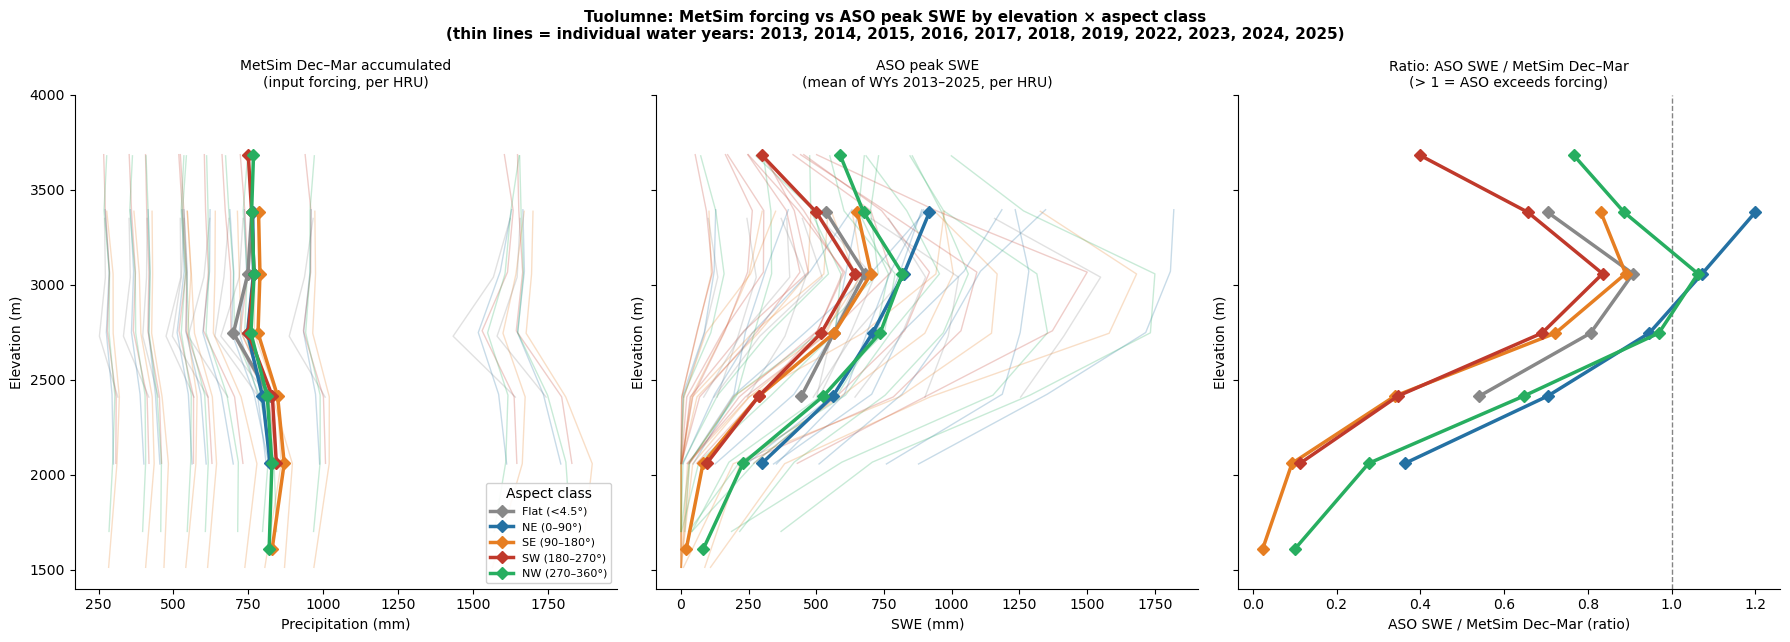

In [9]:

# ── ASO SWE vs MetSim Dec-Mar: differences across 5 aspect classes ─────────────
#
# For each water year with an ASO flight, compute per-HRU mean SWE by rasterizing
# the HRU polygons onto the ASO grid. Compare against MetSim Dec-Mar accumulation
# per HRU. Plot by elevation × aspect class to reveal aspect-driven biases.

import rasterio
from rasterio.features import rasterize
import warnings
warnings.filterwarnings('ignore')

SHP_PATH = ('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect'
            '/shapefiles/catchment/Tuolumne_River_distributed_elevAspect_HRUs_elevation_aspect.shp')

ASPECT_LABELS = {0: 'Flat (<4.5°)', 1: 'NE (0–90°)', 2: 'SE (90–180°)',
                 3: 'SW (180–270°)', 4: 'NW (270–360°)'}
ASPECT_COLORS = {0: '#888888', 1: '#2471a3', 2: '#e67e22', 3: '#c0392b', 4: '#27ae60'}

# ── Load HRU shapefile in ASO CRS ─────────────────────────────────────────────
shp_utm = gpd.read_file(SHP_PATH).to_crs(epsg=32611).sort_values('HRU_ID').reset_index(drop=True)
ac_col  = 'aspectClass' if 'aspectClass' in shp_utm.columns else 'aspectClas'
shapes  = list(zip(shp_utm.geometry, shp_utm['HRU_ID'].astype(int)))

# ── Per-HRU mean ASO SWE for each available water year ────────────────────────
wy_hru_swe = {}   # WY → np.array (28,) mean SWE mm per HRU

for wy, (d_flight, f_aso) in sorted(wy_flights.items()):
    aso = rxr.open_rasterio(f_aso, masked=True).squeeze()
    hru_grid = rasterize(
        shapes,
        out_shape=aso.shape,
        transform=aso.rio.transform(),
        fill=0,
        dtype='int32'
    )
    swe_px = aso.values * 1000.0   # m → mm
    hru_swe = np.full(len(shp_utm), np.nan)
    for i, hru_id in enumerate(shp_utm['HRU_ID'].astype(int)):
        mask = (hru_grid == hru_id)
        vals = swe_px[mask]
        valid = vals[~np.isnan(vals) & (vals >= 0)]
        if len(valid) > 0:
            hru_swe[i] = np.nanmean(valid)
    wy_hru_swe[wy] = hru_swe

# ── Build per-HRU records aligned with hru_meta ───────────────────────────────
# hru_meta index = HRU_ID 1..28; shp_utm sorted by HRU_ID
ac_vals  = shp_utm[ac_col].values.astype(int)   # aspect class per HRU (order 1..28)
ec_vals  = shp_utm['elevClass'].values.astype(int)
em_vals  = shp_utm['elev_mean'].values

aspect_classes = sorted(np.unique(ac_vals))
elev_bands     = sorted(np.unique(ec_vals))
band_elev      = {ec: em_vals[ec_vals == ec].mean() for ec in elev_bands}

# ── Figure: 2 panels (MetSim | ASO) + ratio ────────────────────────────────────
years_both = sorted(set(wy_hru_swe) & set(wy_metsim_prof))

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), sharey=True)
ax_ms, ax_aso, ax_rat = axes

# Thin alpha for individual years, thick for mean
ALPHA_YR = 0.25
LW_MEAN  = 2.5

# Accumulators for mean computation: aspect → {ec: [values across years]}
ms_by_ac  = {ac: {ec: [] for ec in elev_bands} for ac in aspect_classes}
swe_by_ac = {ac: {ec: [] for ec in elev_bands} for ac in aspect_classes}

for wy in years_both:
    metsim_ser = wy_metsim_prof[wy]   # Series: HRU_ID → Dec-Mar mm

    for i, hru_id in enumerate(shp_utm['HRU_ID'].astype(int)):
        ac = ac_vals[i]
        ec = ec_vals[i]
        ms_val  = metsim_ser.get(hru_id, np.nan)
        swe_val = wy_hru_swe[wy][i]
        if not np.isnan(ms_val):
            ms_by_ac[ac][ec].append(ms_val)
        if not np.isnan(swe_val):
            swe_by_ac[ac][ec].append(swe_val)

    # Plot individual year lines per aspect class (light)
    for ac in aspect_classes:
        color = ASPECT_COLORS[ac]
        hrus_ac = [i for i, a in enumerate(ac_vals) if a == ac]

        ms_e  = [em_vals[i] for i in hrus_ac]
        ms_v  = [metsim_ser.get(shp_utm['HRU_ID'].iloc[i], np.nan) for i in hrus_ac]
        swe_e = [em_vals[i] for i in hrus_ac]
        swe_v = [wy_hru_swe[wy][i] for i in hrus_ac]

        order_ms  = np.argsort(ms_e)
        order_swe = np.argsort(swe_e)

        ax_ms.plot(
            [ms_v[j] for j in order_ms],
            [ms_e[j] for j in order_ms],
            color=color, alpha=ALPHA_YR, lw=1.0, zorder=2
        )
        ax_aso.plot(
            [swe_v[j] for j in order_swe],
            [swe_e[j] for j in order_swe],
            color=color, alpha=ALPHA_YR, lw=1.0, zorder=2
        )

# ── Mean lines per aspect class ───────────────────────────────────────────────
for ac in aspect_classes:
    color = ASPECT_COLORS[ac]
    label = ASPECT_LABELS[ac]

    ms_mean_x, ms_mean_y   = [], []
    swe_mean_x, swe_mean_y = [], []
    rat_x, rat_y           = [], []

    for ec in elev_bands:
        ey = band_elev[ec]
        ms_vals  = ms_by_ac[ac][ec]
        swe_vals = swe_by_ac[ac][ec]
        ms_m     = np.nanmean(ms_vals)  if ms_vals  else np.nan
        swe_m    = np.nanmean(swe_vals) if swe_vals else np.nan
        ms_mean_x.append(ms_m);   ms_mean_y.append(ey)
        swe_mean_x.append(swe_m); swe_mean_y.append(ey)
        rat_x.append(swe_m / ms_m if (not np.isnan(ms_m) and ms_m > 0) else np.nan)
        rat_y.append(ey)

    ax_ms.plot(ms_mean_x,  ms_mean_y,  color=color, lw=LW_MEAN, marker='D', ms=6,
               label=label, zorder=5)
    ax_aso.plot(swe_mean_x, swe_mean_y, color=color, lw=LW_MEAN, marker='D', ms=6,
                label=label, zorder=5)
    ax_rat.plot(rat_x, rat_y, color=color, lw=LW_MEAN, marker='D', ms=6,
                label=label, zorder=5)

# ── Ratio panel reference line ─────────────────────────────────────────────────
ax_rat.axvline(1.0, color='#333333', lw=1.0, ls='--', alpha=0.6, label='ASO = MetSim')

# ── Formatting ────────────────────────────────────────────────────────────────
for ax, title in zip(axes, [
        'MetSim Dec–Mar accumulated\n(input forcing, per HRU)',
        f'ASO peak SWE\n(mean of WYs {min(years_both)}–{max(years_both)}, per HRU)',
        'Ratio: ASO SWE / MetSim Dec–Mar\n(> 1 = ASO exceeds forcing)'
]):
    ax.set_ylabel('Elevation (m)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(1400, 4000)

ax_ms.set_xlabel('Precipitation (mm)', fontsize=10)
ax_aso.set_xlabel('SWE (mm)', fontsize=10)
ax_rat.set_xlabel('ASO SWE / MetSim Dec–Mar (ratio)', fontsize=10)

# Shared legend
handles, labels_ = ax_ms.get_legend_handles_labels()
ax_ms.legend(handles, labels_, fontsize=8, loc='lower right', framealpha=0.9,
             title='Aspect class')

fig.suptitle(
    f'Tuolumne: MetSim forcing vs ASO peak SWE by elevation × aspect class\n'
    f'(thin lines = individual water years: {", ".join(str(y) for y in years_both)})',
    fontsize=11, fontweight='600'
)
fig.tight_layout()
plt.show()


Area-weighted mean of f(e) = 1.00000  (1.0 = perfect conservation)
Basin-mean MetSim Dec-Mar  = 771.7 mm
Basin-mean ASO SWE         = 601.2 mm

 Band   Elev (m)    SWE (mm)     f(e)   Area (km²)
    2       1607        50.5    0.084         30.4
    3       2060       176.4    0.293         30.2
    4       2414       421.7    0.701         76.9
    5       2746       618.3    1.028        256.3
    6       3059       733.2    1.220        270.6
    7       3383       656.0    1.091         97.1
    8       3682       443.8    0.738         13.0


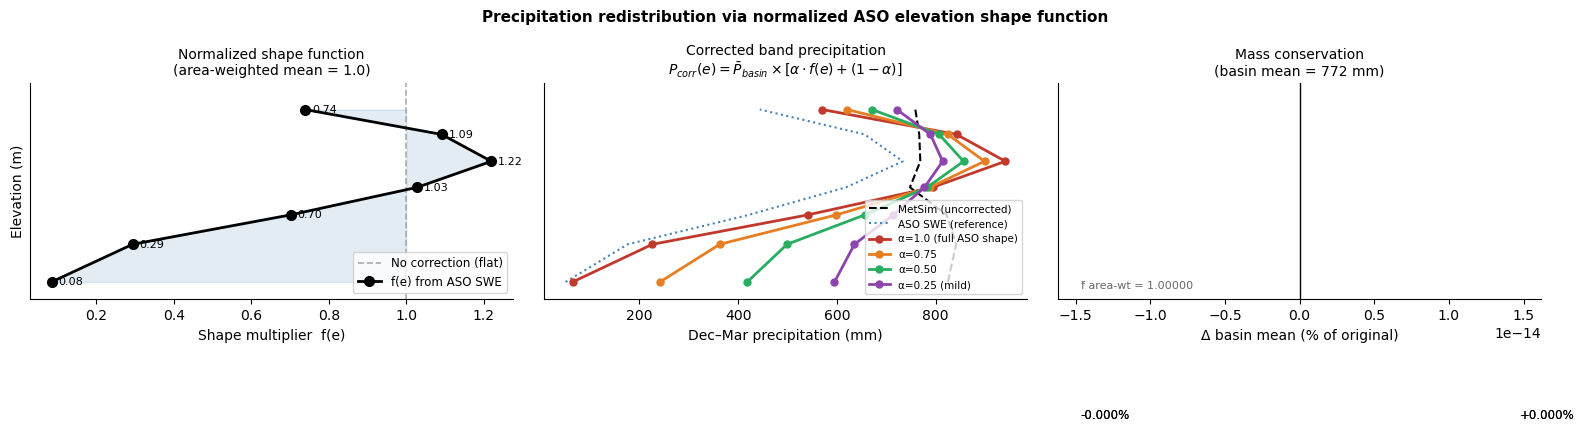

In [10]:

# ── Normalized ASO elevation shape function ────────────────────────────────────
#
# Derive a precipitation redistribution multiplier from ASO SWE.
# Elevation-only: aspect differences reflect sublimation/melt, not precipitation.
#
# f(e) = SWE(e) / area_weighted_mean_SWE
# Area-weighted mean of f = 1.0 exactly → basin-total precipitation conserved.
#
# Blending: f_blend(e, α) = α × f(e) + (1-α) × 1.0
# Corrected per-HRU forcing: P_corrected = P_basin_mean × f_blend(elevClass)

# ── HRU areas (from UTM-projected shapefile — already loaded above) ────────────
hru_areas = shp_utm.geometry.area.values   # m² per HRU, ordered by HRU_ID

# ── Mean ASO SWE per elevation band (collapse aspect + years) ─────────────────
band_swe_mean = {}
for ec in elev_bands:
    vals = [wy_hru_swe[wy][i]
            for wy in years_both
            for i, eec in enumerate(ec_vals)
            if eec == ec and not np.isnan(wy_hru_swe[wy][i]) and wy_hru_swe[wy][i] >= 0]
    band_swe_mean[ec] = np.nanmean(vals) if vals else np.nan

# Area per elevation band
band_area = {ec: hru_areas[ec_vals == ec].sum() for ec in elev_bands}
total_area = sum(band_area.values())

# Area-weighted basin mean SWE
mu_swe = sum(band_swe_mean[ec] * band_area[ec] / total_area
             for ec in elev_bands if not np.isnan(band_swe_mean[ec]))

# Normalized shape multiplier f(e): area-weighted mean = 1.0
shape_f = {ec: band_swe_mean[ec] / mu_swe if not np.isnan(band_swe_mean.get(ec)) else np.nan
           for ec in elev_bands}
f_wt_mean = sum(shape_f[ec] * band_area[ec] / total_area
                for ec in elev_bands if not np.isnan(shape_f[ec]))

# ── MetSim basin-mean Dec-Mar precipitation (area-weighted) ───────────────────
band_ms_mean = {}
for ec in elev_bands:
    vals = [wy_metsim_prof[wy].get(shp_utm['HRU_ID'].iloc[i], np.nan)
            for wy in years_both
            for i, eec in enumerate(ec_vals) if eec == ec]
    band_ms_mean[ec] = np.nanmean([v for v in vals if not np.isnan(v)])

ms_basin_mean = sum(band_ms_mean[ec] * band_area[ec] / total_area
                    for ec in elev_bands if not np.isnan(band_ms_mean.get(ec, np.nan)))

print(f'Area-weighted mean of f(e) = {f_wt_mean:.5f}  (1.0 = perfect conservation)')
print(f'Basin-mean MetSim Dec-Mar  = {ms_basin_mean:.1f} mm')
print(f'Basin-mean ASO SWE         = {mu_swe:.1f} mm\n')
print(f'{"Band":>5}  {"Elev (m)":>9}  {"SWE (mm)":>10}  {"f(e)":>7}  {"Area (km²)":>11}')
for ec in elev_bands:
    print(f'{ec:>5}  {band_elev[ec]:>9.0f}  {band_swe_mean[ec]:>10.1f}  '
          f'{shape_f[ec]:>7.3f}  {band_area[ec]/1e6:>11.1f}')

# ── Blended correction for α ∈ {1.0, 0.75, 0.5, 0.25} ────────────────────────
ALPHAS        = [1.0, 0.75, 0.5, 0.25]
ALPHA_COLORS  = {1.0: '#c0392b', 0.75: '#e67e22', 0.5: '#27ae60', 0.25: '#8e44ad'}
ALPHA_LABELS  = {1.0: 'α=1.0 (full ASO shape)',
                 0.75: 'α=0.75',
                 0.5:  'α=0.50',
                 0.25: 'α=0.25 (mild)'}

band_elevs_list = [band_elev[ec] for ec in elev_bands]
f_list          = [shape_f[ec]   for ec in elev_bands]
ms_list         = [band_ms_mean[ec] for ec in elev_bands]
swe_list        = [band_swe_mean[ec] for ec in elev_bands]

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
ax_f, ax_p, ax_chk = axes

# Panel 1 — Shape function
ax_f.axvline(1.0, color='#aaaaaa', lw=1.2, ls='--', label='No correction (flat)')
ax_f.plot(f_list, band_elevs_list, 'ko-', lw=2.0, ms=7, label='f(e) from ASO SWE')
ax_f.fill_betweenx(band_elevs_list, [1.0]*len(elev_bands), f_list,
                   alpha=0.15, color='steelblue')
for ec, ey, fv in zip(elev_bands, band_elevs_list, f_list):
    ax_f.annotate(f'{fv:.2f}', xy=(fv, ey), xytext=(5, 0),
                  textcoords='offset points', fontsize=8, va='center')
ax_f.set_xlabel('Shape multiplier  f(e)', fontsize=10)
ax_f.set_ylabel('Elevation (m)', fontsize=10)
ax_f.set_title('Normalized shape function\n(area-weighted mean = 1.0)', fontsize=10)
ax_f.legend(fontsize=8.5, loc='lower right')
ax_f.spines[['top', 'right']].set_visible(False)
ax_f.set_ylim(1400, 4000)

# Panel 2 — Corrected precipitation per band
ax_p.plot(ms_list, band_elevs_list, 'k--', lw=1.5, label='MetSim (uncorrected)', zorder=2)
ax_p.plot(swe_list, band_elevs_list, color='steelblue', ls=':', lw=1.5,
          label='ASO SWE (reference)', zorder=2)
for alpha in ALPHAS:
    P_corr = [ms_basin_mean * (alpha * fv + (1 - alpha)) for fv in f_list]
    ax_p.plot(P_corr, band_elevs_list, color=ALPHA_COLORS[alpha],
              lw=2.0, marker='o', ms=5, label=ALPHA_LABELS[alpha], zorder=3)
ax_p.set_xlabel('Dec–Mar precipitation (mm)', fontsize=10)
ax_p.set_title('Corrected band precipitation\n'
               r'$P_{corr}(e) = \bar{P}_{basin} \times [\alpha \cdot f(e) + (1-\alpha)]$',
               fontsize=10)
ax_p.legend(fontsize=7.5, loc='lower right')
ax_p.spines[['top', 'right']].set_visible(False)

# Panel 3 — Conservation error as % of basin mean
pct_errors = []
for alpha in ALPHAS:
    total = sum(ms_basin_mean * (alpha * shape_f[ec] + (1 - alpha)) * band_area[ec]
                for ec in elev_bands if not np.isnan(shape_f[ec])) / total_area
    pct_errors.append((total - ms_basin_mean) / ms_basin_mean * 100)

bars = ax_chk.barh([ALPHA_LABELS[a] for a in ALPHAS], pct_errors,
                   color=[ALPHA_COLORS[a] for a in ALPHAS], alpha=0.82)
ax_chk.axvline(0, color='black', lw=1.0)
for bar, pct in zip(bars, pct_errors):
    ax_chk.text(pct + 0.002 * max(abs(p) for p in pct_errors),
                bar.get_y() + bar.get_height() / 2,
                f'{pct:+.3f}%', va='center', fontsize=8.5)
ax_chk.set_xlabel('Δ basin mean (% of original)', fontsize=10)
ax_chk.set_title(f'Mass conservation\n(basin mean = {ms_basin_mean:.0f} mm)', fontsize=10)
ax_chk.text(0.05, 0.05, f'f̄ area-wt = {f_wt_mean:.5f}',
            transform=ax_chk.transAxes, fontsize=8, color='#666666')
ax_chk.spines[['top', 'right']].set_visible(False)

fig.suptitle('Precipitation redistribution via normalized ASO elevation shape function',
             fontsize=11, fontweight='600')
fig.tight_layout()
plt.show()


In [12]:

# ── Apply α=0.5 precipitation gradient correction to all 540 forcing files ─────
#
# Redistribution rule (mass-conserving per month):
#   P_corrected(HRU) = P_basin_mean_monthly × [α × f(elevClass) + (1−α)]
#   Scale factor     = P_corrected(HRU) / P_original(HRU)
#
# f(e) is the normalized ASO shape function (area-weighted mean = 1.0).
# α = 0.5 blends 50% of the shape gradient with a flat (no-correction) field.
# Months with < 0.5 mm area-weighted basin mean are left unchanged (dry months).

from pathlib import Path
import shutil
import netCDF4 as nc

ALPHA   = 0.5
IN_DIR  = Path(FORCING_PATH)
OUT_DIR = Path(FORCING_PATH).parent / 'basin_averaged_data_gradient_corrected'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Blended shape multiplier per elevation class ──────────────────────────────
f_blend     = {ec: ALPHA * shape_f[ec] + (1 - ALPHA) for ec in elev_bands}
f_blend_hru = np.array([f_blend[ec_vals[i]] for i in range(len(ec_vals))])  # (28,)

print(f'α = {ALPHA}\n')
print(f'{"Band":>5}  {"Elev (m)":>9}  {"f(e)":>7}  {"f_blend":>8}  {"Dec-Mar corr (mm)":>18}')
for ec in elev_bands:
    est = ms_basin_mean * f_blend[ec]
    print(f'{ec:>5}  {band_elev[ec]:>9.0f}  {shape_f[ec]:>7.3f}  {f_blend[ec]:>8.3f}  {est:>18.1f}')

# ── Verify HRU ordering matches shapefile ─────────────────────────────────────
sample_file = sorted(IN_DIR.glob('*.nc'))[0]
with nc.Dataset(sample_file) as _ds:
    nc_hru_ids  = _ds['hruId'][:].astype(int)
    shp_hru_ids = shp_utm['HRU_ID'].astype(int).values
assert np.all(nc_hru_ids == shp_hru_ids), \
    f'HRU ID mismatch between netCDF ({nc_hru_ids}) and shapefile ({shp_hru_ids})'
print(f'\nHRU order verified: {nc_hru_ids.tolist()}')

# ── Process all files ─────────────────────────────────────────────────────────
files      = sorted(IN_DIR.glob('*.nc'))
n_total    = len(files)
processed  = 0
skipped    = 0

for idx, f_in in enumerate(files):
    f_out = OUT_DIR / f_in.name

    with nc.Dataset(f_in) as src:
        pptrate_ma = src['pptrate'][:]    # (time, hru) — masked array, mm/s

        # Monthly total per HRU (mm) — assume 1-hour timestep throughout
        ppt_total = np.array(pptrate_ma.filled(0.0)).sum(axis=0) * 3600.0  # (28,)

        # Area-weighted basin mean (mm)
        basin_mean = np.average(ppt_total, weights=hru_areas)

        # Dry month: copy unchanged, nothing to redistribute
        if basin_mean < 0.5:
            shutil.copy2(f_in, f_out)
            skipped += 1
            if (idx + 1) % 60 == 0:
                print(f'  [{idx+1}/{n_total}] ...')
            continue

        # Per-HRU scale factor
        target = basin_mean * f_blend_hru              # (28,)
        # HRUs with < 0.01 mm (trace precip): keep scale = 1 to avoid amplifying noise
        scale = np.where(ppt_total > 0.01, target / ppt_total, 1.0)

        # Corrected pptrate: broadcast scale (28,) over time axis
        pptrate_raw  = np.array(pptrate_ma)            # (time, 28), NaN where masked
        pptrate_corr = pptrate_raw * scale[np.newaxis, :]

    # Write: copy all variables; replace pptrate ──────────────────────────────
    with nc.Dataset(f_in) as src, nc.Dataset(f_out, 'w') as dst:
        # Global attributes
        dst.setncatts({k: src.getncattr(k) for k in src.ncattrs()})
        old_hist = getattr(src, 'history', '')
        dst.history = (old_hist + ' | pptrate gradient-corrected: '
                       f'alpha={ALPHA}, ASO SWE shape function (elev only)')

        # Dimensions
        for dname, dim in src.dimensions.items():
            dst.createDimension(dname, None if dim.isunlimited() else len(dim))

        # Variables
        for vname, var in src.variables.items():
            fill_kw = {}
            if hasattr(var, '_FillValue'):
                fill_kw['fill_value'] = var._FillValue
            dst_var = dst.createVariable(vname, var.datatype, var.dimensions, **fill_kw)
            dst_var.setncatts({k: var.getncattr(k) for k in var.ncattrs()
                               if k != '_FillValue'})
            if vname == 'pptrate':
                # Restore fill mask from original
                if hasattr(pptrate_ma, 'mask') and np.any(pptrate_ma.mask):
                    fv = fill_kw.get('fill_value', np.nan)
                    pptrate_corr[pptrate_ma.mask] = fv
                dst_var[:] = pptrate_corr
            else:
                dst_var[:] = var[:]

    processed += 1
    if (idx + 1) % 60 == 0:
        print(f'  [{idx+1}/{n_total}] {f_in.name}  basin_mean={basin_mean:.1f} mm')

print(f'\nDone.  Corrected: {processed}  |  Dry-month copies: {skipped}  |  Total: {processed+skipped}')
print(f'Output directory: {OUT_DIR}')


α = 0.5

 Band   Elev (m)     f(e)   f_blend   Dec-Mar corr (mm)
    2       1607    0.084     0.542               418.3
    3       2060    0.293     0.647               499.1
    4       2414    0.701     0.851               656.5
    5       2746    1.028     1.014               782.6
    6       3059    1.220     1.110               856.4
    7       3383    1.091     1.046               806.9
    8       3682    0.738     0.869               670.7

HRU order verified: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
  [60/540] Tuolumne_River_distributed_elevAspect_METSIM_remapped_metsim_198512.nc  basin_mean=156.5 mm
  [120/540] Tuolumne_River_distributed_elevAspect_METSIM_remapped_metsim_199012.nc  basin_mean=54.5 mm
  [180/540] Tuolumne_River_distributed_elevAspect_METSIM_remapped_metsim_199512.nc  basin_mean=258.3 mm
  [240/540] Tuolumne_River_distributed_elevAspect_METSIM_remapped_metsim_200012.nc  basin_mean=31.2 mm
  [30

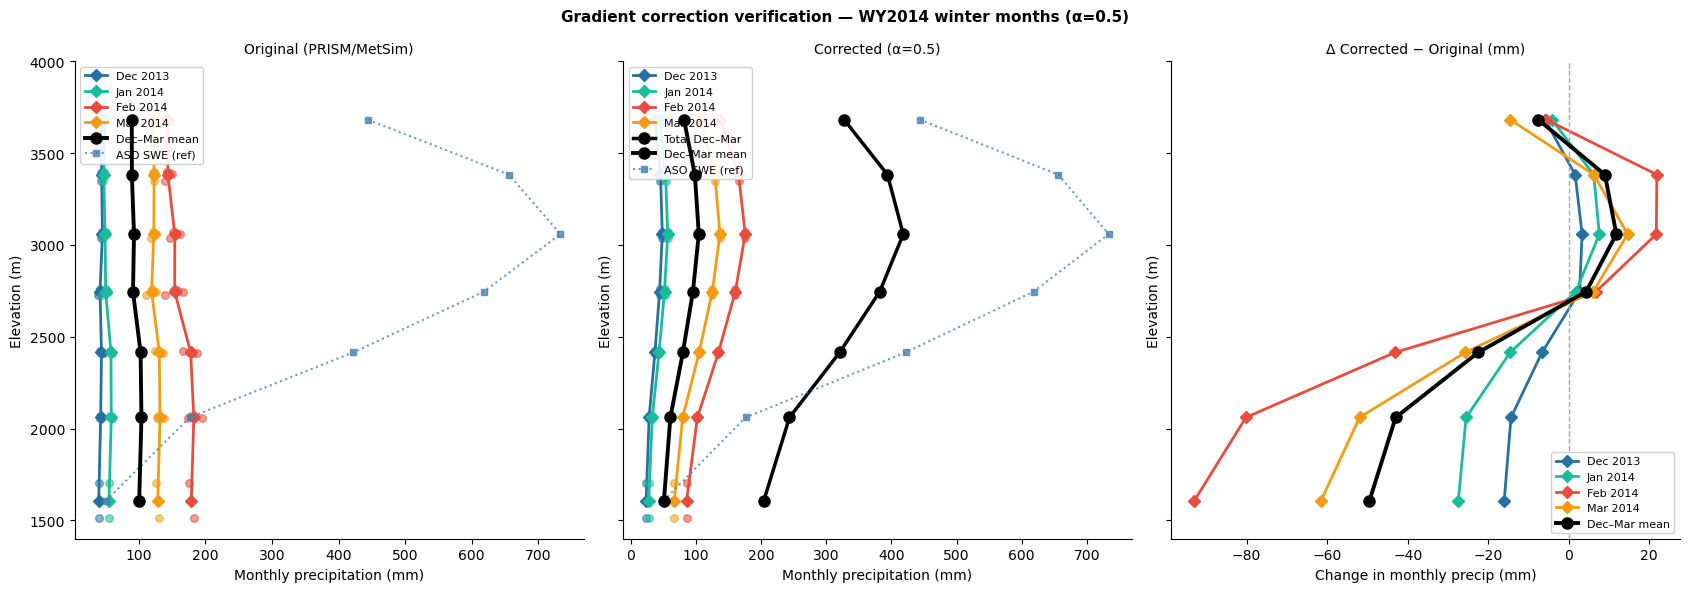


── Mass conservation check ──────────────────────────────────────
Month            Orig (mm)   Corr (mm)     Δ (%)
Dec 2013             43.77       43.77   +0.0000%
Jan 2014             51.20       51.20   -0.0000%
Feb 2014            158.33      158.33   -0.0000%
Mar 2014            123.48      123.48   -0.0000%


In [20]:

# ── Verification: before/after precipitation gradient ────────────────────────
#
# Load corrected files for Dec–Mar and compare the elevation gradient
# against the uncorrected originals. Also verify basin-mean conservation.

VERIFY_MONTHS = [(2013, 12), (2014, 1), (2014, 2), (2014, 3)]   # WY2014 winter
MO_NAMES = {12: 'Dec', 1: 'Jan', 2: 'Feb', 3: 'Mar'}

fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)
ax_raw, ax_corr, ax_diff = axes

# Accumulators for mean across months
orig_by_ec  = {ec: [] for ec in elev_bands}
corr_by_ec  = {ec: [] for ec in elev_bands}
conservation_check = []

for (yr, mo) in VERIFY_MONTHS:
    fname = f'Tuolumne_River_distributed_elevAspect_METSIM_remapped_metsim_{yr:04d}{mo:02d}.nc'
    f_orig = IN_DIR / fname
    f_corr = OUT_DIR / fname

    with nc.Dataset(f_orig) as ds:
        ppt_orig = np.array(ds['pptrate'][:]).sum(axis=0) * 3600.0  # (28,) mm

    with nc.Dataset(f_corr) as ds:
        ppt_corr = np.array(ds['pptrate'][:]).sum(axis=0) * 3600.0  # (28,) mm

    # Basin means
    bm_orig = np.average(ppt_orig, weights=hru_areas)
    bm_corr = np.average(ppt_corr, weights=hru_areas)
    conservation_check.append({'month': f'{MO_NAMES[mo]} {yr}',
                               'orig': bm_orig, 'corr': bm_corr,
                               'diff_pct': (bm_corr - bm_orig) / bm_orig * 100})

    color = MO_COLORS.get(mo, 'grey')
    label = f'{MO_NAMES[mo]} {yr}'

    # Per-HRU scatter by elevation
    ax_raw.scatter(ppt_orig, em_vals, color=color, alpha=0.55, s=30, zorder=2)
    ax_corr.scatter(ppt_corr, em_vals, color=color, alpha=0.55, s=30, zorder=2)

    # Band means
    for ec in elev_bands:
        mask = (ec_vals == ec)
        orig_by_ec[ec].append(ppt_orig[mask].mean())
        corr_by_ec[ec].append(ppt_corr[mask].mean())

    bm_orig_ec = [ppt_orig[ec_vals == ec].mean() for ec in elev_bands]
    bm_corr_ec = [ppt_corr[ec_vals == ec].mean() for ec in elev_bands]
    band_elevs_list = [band_elev[ec] for ec in elev_bands]

    ax_raw.plot(bm_orig_ec,  band_elevs_list, color=color, lw=2.0, marker='D', ms=6, label=label)
    ax_corr.plot(bm_corr_ec, band_elevs_list, color=color, lw=2.0, marker='D', ms=6, label=label)
# add the total Dec-Mar ppt for each elevation band to the ax_corr
ax_corr.plot([sum(corr_by_ec[ec]) for ec in elev_bands], band_elevs_list, color='black', lw=2.5, marker='o', ms=8, label='Total Dec–Mar')

# ── Mean across all 4 months ──────────────────────────────────────────────────
mean_orig_ec = [np.mean(orig_by_ec[ec]) for ec in elev_bands]
mean_corr_ec = [np.mean(corr_by_ec[ec]) for ec in elev_bands]
band_elevs_list = [band_elev[ec] for ec in elev_bands]

ax_raw.plot(mean_orig_ec,  band_elevs_list, 'k-',  lw=2.8, marker='o', ms=8, zorder=6, label='Dec–Mar mean')
ax_corr.plot(mean_corr_ec, band_elevs_list, 'k-',  lw=2.8, marker='o', ms=8, zorder=6, label='Dec–Mar mean')

# ── Diff panel: corrected − original (mm) ────────────────────────────────────
for (yr, mo), color in zip(VERIFY_MONTHS, [MO_COLORS.get(m, 'grey') for _, m in VERIFY_MONTHS]):
    fname = f'Tuolumne_River_distributed_elevAspect_METSIM_remapped_metsim_{yr:04d}{mo:02d}.nc'
    with nc.Dataset(IN_DIR / fname) as ds:
        ppt_orig = np.array(ds['pptrate'][:]).sum(axis=0) * 3600.0
    with nc.Dataset(OUT_DIR / fname) as ds:
        ppt_corr = np.array(ds['pptrate'][:]).sum(axis=0) * 3600.0
    diff_ec = [ppt_corr[ec_vals == ec].mean() - ppt_orig[ec_vals == ec].mean()
               for ec in elev_bands]
    ax_diff.plot(diff_ec, band_elevs_list, color=color, lw=2.0, marker='D', ms=6,
                 label=f'{MO_NAMES[mo]} {yr}')


mean_diff_ec = [c - o for c, o in zip(mean_corr_ec, mean_orig_ec)]
ax_diff.plot(mean_diff_ec, band_elevs_list, 'k-', lw=2.8, marker='o', ms=8, zorder=6,
             label='Dec–Mar mean')
ax_diff.axvline(0, color='#aaaaaa', lw=1.0, ls='--')

# ── ASO SWE reference on both precip panels ────────────────────────────────────
swe_list = [band_swe_mean[ec] for ec in elev_bands]
for ax in (ax_raw, ax_corr):
    ax.plot(swe_list, band_elevs_list, color='steelblue', lw=1.5, ls=':', marker='s', ms=5,
            alpha=0.8, label='ASO SWE (ref)', zorder=4)

# ── Formatting ────────────────────────────────────────────────────────────────
for ax, title in zip(axes, ['Original (PRISM/MetSim)', f'Corrected (α={ALPHA})', 'Δ Corrected − Original (mm)']):
    ax.set_ylabel('Elevation (m)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='upper left' if ax != ax_diff else 'lower right', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(1400, 4000)
ax_raw.set_xlabel('Monthly precipitation (mm)', fontsize=10)
ax_corr.set_xlabel('Monthly precipitation (mm)', fontsize=10)
ax_diff.set_xlabel('Change in monthly precip (mm)', fontsize=10)

fig.suptitle(f'Gradient correction verification — WY2014 winter months (α={ALPHA})', fontsize=11, fontweight='600')
fig.tight_layout()
plt.show()

# ── Mass conservation table ────────────────────────────────────────────────────
print('\n── Mass conservation check ──────────────────────────────────────')
print(f'{"Month":<14}  {"Orig (mm)":>10}  {"Corr (mm)":>10}  {"Δ (%)":>8}')
for row in conservation_check:
    print(f'{row["month"]:<14}  {row["orig"]:>10.2f}  {row["corr"]:>10.2f}  {row["diff_pct"]:>+8.4f}%')
